# ISM — expand phase: impulse responses & out-of-sample forecasts

Companion to `ISM_replication.ipynb`. Reproduces:
- **Figure 2** — cumulative log-PCE-price response to a 1 sd ISM / S+ / S- surprise (Eq. 9)
- **Figure 3** — response of the ISM index to (a) Romer-Romer attempted-disinflation
  dates and (b) the Kanzig (2021) oil-supply news shock (Eq. 15)
- **Table 2** — out-of-sample adaptive-LASSO forecasts (baseline vs baseline+ISM),
  RMSFE ratio and Giacomini-White test (Eq. 14)

Unlike the core notebook (engine inlined), this one **imports the tested modules**
in `src/ism` (`local_projection`, `oos_lasso`, `external_data`) — these stats
routines are unit-tested and better kept in one place than duplicated. No install
needed; we just add `src/` to the path.

## Setup & build the ISM index from the pinned category set

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO_ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT/"src"))
try:
    from dotenv import load_dotenv; load_dotenv(REPO_ROOT/".env")
except Exception: pass

from ism.engine import ISMConfig, compute_ism
from ism.datasources import FredClient
from ism import controls as controls_mod
from ism.local_projection import irf_price_to_ism, response_ism_to_shock
from ism.oos_lasso import table2
from ism.external_data import romer_romer_dummy
from ism.transforms import yoy_inflation

BEA = REPO_ROOT/"data"/"raw"/"bea"
def _norm_key(c): c=str(c); return c[1:] if c[:2] in ("IA","LA") else c[:-1]
def _load_bea(table):
    d=json.loads((BEA/f"{table}_M.json").read_text()); df=pd.DataFrame(d["BEAAPI"]["Results"]["Data"])
    df["DataValue"]=pd.to_numeric(df["DataValue"].astype(str).str.replace(",","",regex=False),errors="coerce")
    df["date"]=pd.to_datetime(df["TimePeriod"].astype(str).str.replace("M","-")+"-01",errors="coerce")
    df["key"]=df["SeriesCode"].map(_norm_key); return df

def build_panel():
    keys=pd.read_csv(REPO_ROOT/"config"/"pce_categories.csv")["key"].astype(str).tolist()
    p,n=_load_bea("U20404"),_load_bea("U20405")
    pw=p.pivot_table(index="date",columns="key",values="DataValue",aggfunc="first").sort_index()
    nw=n.pivot_table(index="date",columns="key",values="DataValue",aggfunc="first").sort_index()
    keys=[k for k in keys if k in pw.columns and k in nw.columns]
    infl=100*(np.log(pw[keys])-np.log(pw[keys].shift(1)))
    w=nw[keys].div(nw[keys].sum(axis=1).replace(0,np.nan),axis=0)
    c=infl.index.intersection(w.index); return infl.loc[c], w.loc[c]

infl, weights = build_panel()
res = compute_ism(infl, weights, ISMConfig())
fred = FredClient()
pcepi = fred.series("PCEPI"); pcepi.index = pd.to_datetime(pcepi.index).to_period("M").to_timestamp() if False else pcepi.index
pcepi.index = pd.to_datetime(pcepi.index).to_period("M").to_timestamp()
controls = controls_mod.build_controls(fred)
pce_yoy = controls["pce_yoy"]
print("ISM months:", res.ism.dropna().shape[0], "| controls:", list(controls.columns))

[controls] Barnichon HWI not found -> V/U from 2000 only: Barnichon HWI not found at C:\Users\tbretagne\Dropbox\GitHub\ISMI_Shapiro\ISMI\data\raw\external\barnichon_hwi.csv. Download the 'Composite HWI' file from https://sites.google.com/site/regisbarnichon/data and save it there as two columns (date, index).
ISM months: 808 | controls: ['pce_yoy', 'pce_3m', 'infl_exp_1y', 'vu_ratio', 'oil_wti', 'sp500', 'rdpi_yoy', 'spread_10y_ffr', 'nber_recession']


## Figure 2 — IRF of the PCE price level to ISM / S+ / S- surprises (Eq. 9)

For each shock we estimate, at horizons 0–60 months, the cumulative response of
`100*ln(PCEPI)` to the part of the shock orthogonal to its 12 lags and to
current+12 lags of the controls. Bands: ±1 sd and 90%.

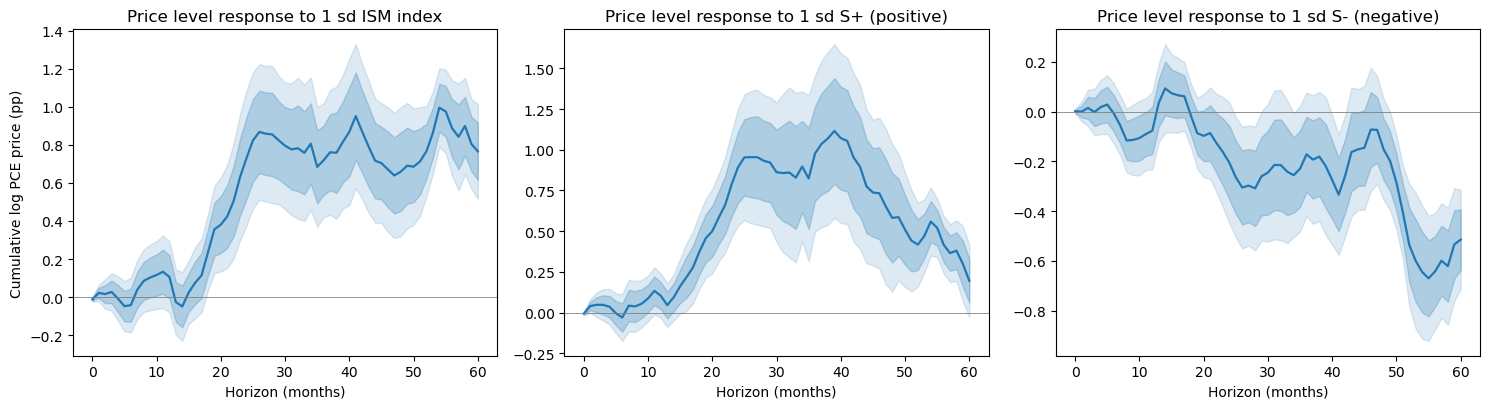

In [2]:
ctrl_for_lp = controls.drop(columns=["pce_yoy"], errors="ignore")
H = range(0, 61)
irf_ism = irf_price_to_ism(pcepi, res.ism,  ctrl_for_lp, horizons=H)
irf_pos = irf_price_to_ism(pcepi, res.s_pos, ctrl_for_lp, horizons=H)
irf_neg = irf_price_to_ism(pcepi, res.s_neg, ctrl_for_lp, horizons=H)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for ax, d, t in zip(axes, [irf_ism, irf_pos, irf_neg], ["ISM index", "S+ (positive)", "S- (negative)"]):
    ax.plot(d["h"], d["beta"], color="tab:blue", lw=1.6)
    ax.fill_between(d["h"], d["lo_90"], d["hi_90"], color="tab:blue", alpha=.15)
    ax.fill_between(d["h"], d["lo_1sd"], d["hi_1sd"], color="tab:blue", alpha=.25)
    ax.axhline(0, color="grey", lw=.6); ax.set_title(f"Price level response to 1 sd {t}")
    ax.set_xlabel("Horizon (months)")
axes[0].set_ylabel("Cumulative log PCE price (pp)")
fig.tight_layout(); fig.savefig(REPO_ROOT/"outputs"/"figure2_irf.png", dpi=130); plt.show()

## Figure 3 — response of the ISM index to external shocks (Eq. 15)

Panel (a): Romer-Romer medium/high-commitment attempted-disinflation dates
(response to the 0/1 event). Panel (b): Kanzig (2021) oil-supply news shock
(response to a 1 sd move). Controls: 12 lags of ISM and 12 lags of the NBER
recession dummy. Bands: ±1 sd and 90%.

Fig 3b skipped (provide data/raw/external/kanzig_oilshock.csv): Kanzig oil-supply news shock not found at C:\Users\tbretagne\Dropbox\GitHub\ISMI_Shapiro\ISMI\data\raw\external\kanzig_oilshock.csv. Download the shock series from https://www.diegokaenzig.com/research and save it there as two columns (date, shock).


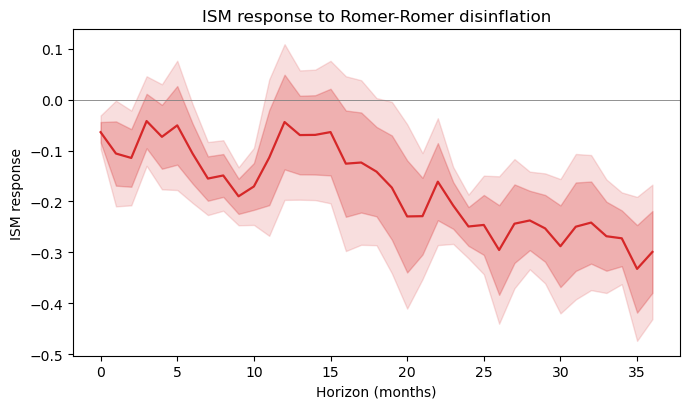

In [3]:
rec = controls["nber_recession"]
rr = romer_romer_dummy(res.ism.index, which="medium_high")
resp_rr = response_ism_to_shock(res.ism, rr, rec, horizons=range(0,37), scale_by_sd=False)

# Kanzig shock is an external file; skip gracefully if absent.
resp_oil = None
try:
    from ism.external_data import load_kanzig_oil_shock
    oil_shock = load_kanzig_oil_shock().reindex(res.ism.index)
    resp_oil = response_ism_to_shock(res.ism, oil_shock, rec, horizons=range(0,37), scale_by_sd=True)
except Exception as e:
    print("Fig 3b skipped (provide data/raw/external/kanzig_oilshock.csv):", e)

ncol = 2 if resp_oil is not None else 1
fig, axes = plt.subplots(1, ncol, figsize=(7*ncol, 4.2), squeeze=False)
def _plot(ax, d, title):
    ax.plot(d["h"], d["beta"], color="tab:red", lw=1.6)
    ax.fill_between(d["h"], d["lo_90"], d["hi_90"], color="tab:red", alpha=.15)
    ax.fill_between(d["h"], d["lo_1sd"], d["hi_1sd"], color="tab:red", alpha=.25)
    ax.axhline(0, color="grey", lw=.6); ax.set_title(title); ax.set_xlabel("Horizon (months)")
_plot(axes[0][0], resp_rr, "ISM response to Romer-Romer disinflation")
if resp_oil is not None: _plot(axes[0][1], resp_oil, "ISM response to Kanzig oil-supply news (1 sd)")
axes[0][0].set_ylabel("ISM response")
fig.tight_layout(); fig.savefig(REPO_ROOT/"outputs"/"figure3_validation.png", dpi=130); plt.show()

## Table 2 — out-of-sample adaptive LASSO (Eq. 14)

Direct h-step forecasts of 12-month PCE inflation at h = 12, 24, 36 over rolling
120-month windows; lambda chosen to minimize RMSFE; baseline vs baseline+ISM with
the Giacomini-White test.

**Runtime note:** this is the heavy cell (rolling windows x lambda grid x
adaptive LASSO). Expect a few minutes. Start with the baseline-only model
(controls=None) for speed, then add controls.

In [4]:
tbl2_baseline = table2(pce_yoy, res.ism, controls=None, horizons=(12,24,36),
                       lam_grid=np.logspace(-3,0,8), window=120)
print("Baseline model (12m PCE inflation only):"); display(tbl2_baseline)

Baseline model (12m PCE inflation only):


,h,rmsfe_base,rmsfe_ism,rmsfe_ratio,GW_F,GW_p,lam_base,lam_ism
0,12,1.4226,1.3137,0.9235,9.89,0.0017,0.001000,0.001000
1,24,1.8045,1.6405,0.9091,7.91,0.0049,0.019307,0.002683
2,36,1.8188,1.6743,0.9205,3.76,0.0525,0.001000,0.002683


In [5]:
# With controls (slower). Uncomment to run.
# tbl2_controls = table2(pce_yoy, res.ism, controls=controls, horizons=(12,24,36),
#                        lam_grid=np.logspace(-3,0,8), window=120)
# display(tbl2_controls)

## Notes
RMSFE ratio < 1 and GW p < 0.05 mean adding the ISM index significantly improves
out-of-sample accuracy. See `docs/methodology.md` and `docs/DECISIONS.md` for the
modelling choices and the options considered at each step.